In [ ]:
import pandas as pd

customers_clean = pd.read_excel("Customers_Cleaned.xlsx")


print(customers_clean.shape)
print(customers_clean["customer_segment"].value_counts())

(90000, 5)
customer_segment
New          45211
Returning    31469
Loyal        13320
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

sampled_customers, _ = train_test_split(
    customers_clean,
    train_size=1000,
    stratify=customers_clean["customer_segment"],
    random_state=42
)

print("Sample Shape:", sampled_customers.shape)

print("\nPopulation Distribution:")
print(customers_clean["customer_segment"].value_counts())

print("\nSample Distribution:")
print(sampled_customers["customer_segment"].value_counts())

print("\nSample Percentage:")
print(
    sampled_customers["customer_segment"]
    .value_counts(normalize=True) * 100
)

Sample Shape: (1000, 5)

Population Distribution:
customer_segment
New          45211
Returning    31469
Loyal        13320
Name: count, dtype: int64

Sample Distribution:
customer_segment
New          502
Returning    350
Loyal        148
Name: count, dtype: int64

Sample Percentage:
customer_segment
New          50.2
Returning    35.0
Loyal        14.8
Name: proportion, dtype: float64


In [38]:
purchase_df = pd.read_csv("customer_purchase_data.csv")

print(purchase_df.shape)
print(purchase_df["customer_segment"].value_counts())



(1000, 3)
customer_segment
New          493
Returning    357
Loyal        150
Name: count, dtype: int64


In [39]:
import pandas as pd
from scipy import stats

df = pd.read_csv("customer_purchase_data.csv")

group_new = df[df["customer_segment"] == "New"]["total_purchase_amount"]
group_returning = df[df["customer_segment"] == "Returning"]["total_purchase_amount"]

t_stat, p_value = stats.ttest_ind(
    group_new,
    group_returning,
    equal_var=False
)

print("New customers:", len(group_new))
print("Returning customers:", len(group_returning))
print("T-Statistic:", t_stat)
print("P-value:", p_value)

New customers: 493
Returning customers: 357
T-Statistic: 1.0789101737374998
P-value: 0.2809391173304652


In [40]:
import pandas as pd

reg_df = pd.read_csv("review_sales_regression.csv")

print("Shape:", reg_df.shape)
print("\nColumns:")
print(reg_df.columns.tolist())

print("\nMissing Values:")
print(reg_df.isnull().sum())

print("\nFirst 5 rows:")
print(reg_df.head())

Shape: (1000, 5)

Columns:
['review_score', 'quantity', 'discount_percent', 'shipping_cost', 'sales_amount']

Missing Values:
review_score        0
quantity            0
discount_percent    0
shipping_cost       0
sales_amount        0
dtype: int64

First 5 rows:
   review_score  quantity  discount_percent  shipping_cost  sales_amount
0             4         2             12.06         155.12      2846.084
1             4         1             10.51         188.03      1584.074
2             4         3              6.30          54.70      3118.690
3             5         3              8.24         177.78      5050.236
4             5         1             13.13         613.53      5009.152


In [42]:
X = reg_df[
    ["review_score", "quantity", "discount_percent", "shipping_cost"]
]

y = reg_df["sales_amount"]

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

print("\nX Columns:")
print(X.columns.tolist())

print("\nY:")
print(y.head())

X Shape: (1000, 4)
Y Shape: (1000,)

X Columns:
['review_score', 'quantity', 'discount_percent', 'shipping_cost']

Y:
0    2846.084
1    1584.074
2    3118.690
3    5050.236
4    5009.152
Name: sales_amount, dtype: float64


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 4)
X_test: (200, 4)
y_train: (800,)
y_test: (200,)


In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("MLR Model trained successfully!")
print("\nIntercept:", model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

MLR Model trained successfully!

Intercept: -1238.5129807364847

Coefficients:
review_score : 2.812358255464286
quantity : 2572.6661641921596
discount_percent : 25.63703715892806
shipping_cost : 6.389077956514484


In [47]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== MULTIPLE LINEAR REGRESSION EVALUATION METRICS ===")
print(f"R-Squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

=== MULTIPLE LINEAR REGRESSION EVALUATION METRICS ===
R-Squared (R²): 0.6616
Mean Absolute Error (MAE): 2009.1342
Mean Squared Error (MSE): 24183283.8817
Root Mean Squared Error (RMSE): 4917.6502


In [48]:
import pandas as pd

cluster_df = pd.read_csv("customer_clustering_data.csv")

print("Shape:", cluster_df.shape)

print("\nColumns:")
print(cluster_df.columns.tolist())

print("\nMissing Values:")
print(cluster_df.isnull().sum())

print("\nFirst 5 rows:")
print(cluster_df.head())

Shape: (1000, 5)

Columns:
['customer_id', 'purchase_frequency', 'total_quantity', 'total_purchase_amount', 'average_order_value']

Missing Values:
customer_id              0
purchase_frequency       0
total_quantity           0
total_purchase_amount    0
average_order_value      0
dtype: int64

First 5 rows:
  customer_id  purchase_frequency  total_quantity  total_purchase_amount  \
0      C00006                   1               4              11101.798   
1      C00007                   1               1              98639.746   
2      C00009                   1               3               9434.846   
3      C00011                   1               3              37140.213   
4      C00013                   1               1              13100.940   

   average_order_value  
0          2775.449500  
1         98639.746000  
2          3144.948667  
3         12380.071000  
4         13100.940000  


In [49]:
from sklearn.preprocessing import StandardScaler

features = [
    "purchase_frequency",
    "total_quantity",
    "total_purchase_amount",
    "average_order_value"
]

X_cluster = cluster_df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Original Shape:", X_cluster.shape)
print("Scaled Shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original Shape: (1000, 4)
Scaled Shape: (1000, 4)

First 5 scaled rows:
[[-0.68050827 -0.18957342 -0.594625   -0.51959539]
 [-0.68050827 -1.06722815  2.9590367   7.79382085]
 [-0.68050827 -0.482125   -0.66229604 -0.48755217]
 [-0.68050827 -0.482125    0.46242192  0.31332384]
 [-0.68050827 -1.06722815 -0.51346849  0.37583809]]


Inertia values:
K=2: 2467.26
K=3: 1618.17
K=4: 1215.48
K=5: 1028.12
K=6: 892.64
K=7: 766.77
K=8: 682.58
K=9: 613.30
K=10: 545.51


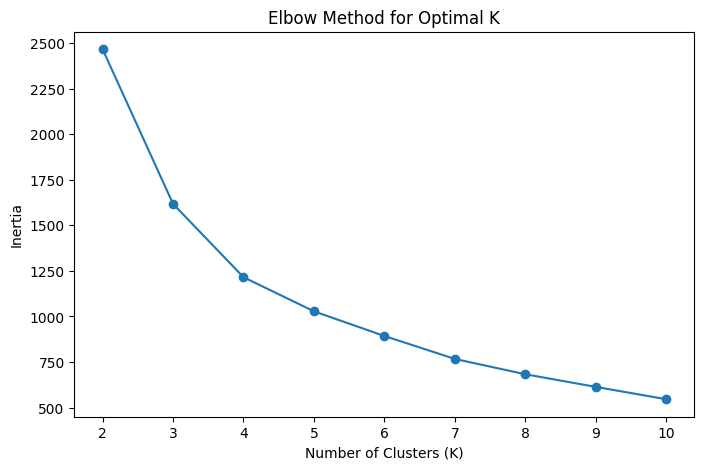

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"K={k}: {value:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.show()

In [51]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

print("\nCluster Distribution:")
print(cluster_df["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Cluster Distribution:
Cluster
0    254
1    718
2     28
Name: count, dtype: int64
